# Langgraph – wprowadzenie

Langgraph to biblioteka pozwalająca wykonywać pipeline'y składające się z wielu etapów, tak zwanych node'ów. Zwykle używamy go do zarządzania flow procesów opartych o integrację z modelami LLM ale nie jest to konieczne

## Pipeline state

Pipeline state to klasa dziedzicząca po `TypedDict` który odpowiada stanowi flow, który jest updatowany z każdym nodem pipeline'u.

W poniższym przykładzie będziemy wczytywać i przetwarzać dane z pliku tekstowego.

In [1]:
from typing import TypedDict


class State(TypedDict):
    file_path: str
    raw_content: str
    parsed_entries: list[dict[str, str]]
    filtered_entries: list[dict[str, str]]
    metrics: dict[str, int]

## Node'y

Pipeline składa się z node'ów, które są połączone krawędziami. W node'ach odbywa się updatowanie stanu pipeline'u.

In [3]:
from langchain_core.runnables import RunnableConfig

In [4]:
debug = True

In [5]:
def read_log_file_node(state: State):
    if debug:
        print("Node: read_log_file |", "State:", state, "\n")
    
    file_path = state["file_path"]
    
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
    
    return {"raw_content": content}

In [6]:
def parse_log_entries_node(state: State):
    if debug:
        print("Node: parse_log_entries |", "State:", state, "\n")

    lines = state["raw_content"].splitlines()
    
    entries = []
    for line in lines:
        if not line.strip():
            continue
        parts = line.split(" | ")
        if len(parts) == 4:
            entries.append({
                "timestamp": parts[0].strip(),
                "level": parts[1].strip(),
                "ip": parts[2].strip(),
                "message": parts[3].strip()
            })
    return {"parsed_entries": entries}

In [7]:
def filter_security_alerts_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: filter_security_alerts |", "State:", state, "| Config:", config, "\n")

    configurable = config.get("configurable", {})
    target_level = configurable.get("alert_level", "CRITICAL")

    filtered = [
        entry for entry in state["parsed_entries"]
        if entry["level"] == target_level
    ]
    return {"filtered_entries": filtered}

In [8]:
def calculate_metrics_node(state: State):
    if debug:
        print("Node: calculate_metrics |", "State:", state, "\n")
    
    entries = state["filtered_entries"]
    
    ip_counts = {}
    for entry in entries:
        ip = entry["ip"]
        ip_counts[ip] = ip_counts.get(ip, 0) + 1
    return {"metrics": ip_counts}

## State graph

In [10]:
from langgraph.graph import StateGraph, START, END

In [11]:
graph = StateGraph(State)

graph.add_node("read_file", read_log_file_node)
graph.add_node("parse_log_entries", parse_log_entries_node)
graph.add_node("filter_security_alerts", filter_security_alerts_node)
graph.add_node("calculate_metrics", calculate_metrics_node)

graph.add_edge(START, "read_file")
graph.add_edge("read_file", "parse_log_entries")
graph.add_edge("parse_log_entries", "filter_security_alerts")
graph.add_edge("filter_security_alerts", "calculate_metrics")
graph.add_edge("calculate_metrics", END)

pipeline = graph.compile()

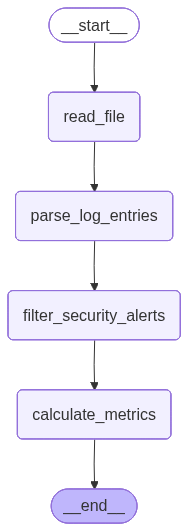

In [13]:
pipeline

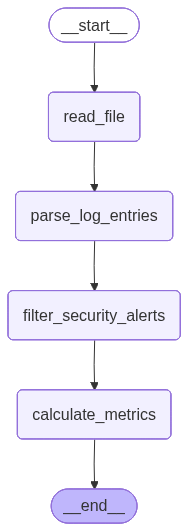

In [12]:
from IPython.display import Image, display

display(Image(pipeline.get_graph().draw_mermaid_png(), width=120))

## Uruchomienie pipeline'u

In [14]:
initial_state = {"file_path": "log_file.log"}
runtime_config = {"configurable": {"alert_level": "CRITICAL"}}

result = pipeline.invoke(initial_state, config=runtime_config)

Node: read_log_file | State: {'file_path': 'log_file.log'} 

Node: parse_log_entries | State: {'file_path': 'log_file.log', 'raw_content': '2026-05-16 12:00:01 | INFO | 192.168.1.10 | User logged in\n2026-05-16 12:01:15 | WARNING | 10.0.0.5 | Failed login attempt\n2026-05-16 12:02:22 | CRITICAL | 172.16.0.44 | SQL Injection detected\n2026-05-16 12:03:05 | INFO | 192.168.1.12 | File downloaded\n2026-05-16 12:04:40 | CRITICAL | 172.16.0.44 | Brute force attack\n2026-05-16 12:05:12 | CRITICAL | 192.168.1.99 | Unauthorized admin access\n'} 

Node: filter_security_alerts | State: {'file_path': 'log_file.log', 'raw_content': '2026-05-16 12:00:01 | INFO | 192.168.1.10 | User logged in\n2026-05-16 12:01:15 | WARNING | 10.0.0.5 | Failed login attempt\n2026-05-16 12:02:22 | CRITICAL | 172.16.0.44 | SQL Injection detected\n2026-05-16 12:03:05 | INFO | 192.168.1.12 | File downloaded\n2026-05-16 12:04:40 | CRITICAL | 172.16.0.44 | Brute force attack\n2026-05-16 12:05:12 | CRITICAL | 192.168.1.99 | 

In [18]:
result.keys()

dict_keys(['file_path', 'raw_content', 'parsed_entries', 'filtered_entries', 'metrics'])

In [24]:
result["filtered_entries"]

[{'timestamp': '2026-05-16 12:02:22',
  'level': 'CRITICAL',
  'ip': '172.16.0.44',
  'message': 'SQL Injection detected'},
 {'timestamp': '2026-05-16 12:04:40',
  'level': 'CRITICAL',
  'ip': '172.16.0.44',
  'message': 'Brute force attack'},
 {'timestamp': '2026-05-16 12:05:12',
  'level': 'CRITICAL',
  'ip': '192.168.1.99',
  'message': 'Unauthorized admin access'}]

In [17]:
result

{'file_path': 'log_file.log',
 'raw_content': '2026-05-16 12:00:01 | INFO | 192.168.1.10 | User logged in\n2026-05-16 12:01:15 | WARNING | 10.0.0.5 | Failed login attempt\n2026-05-16 12:02:22 | CRITICAL | 172.16.0.44 | SQL Injection detected\n2026-05-16 12:03:05 | INFO | 192.168.1.12 | File downloaded\n2026-05-16 12:04:40 | CRITICAL | 172.16.0.44 | Brute force attack\n2026-05-16 12:05:12 | CRITICAL | 192.168.1.99 | Unauthorized admin access\n',
 'parsed_entries': [{'timestamp': '2026-05-16 12:00:01',
   'level': 'INFO',
   'ip': '192.168.1.10',
   'message': 'User logged in'},
  {'timestamp': '2026-05-16 12:01:15',
   'level': 'WARNING',
   'ip': '10.0.0.5',
   'message': 'Failed login attempt'},
  {'timestamp': '2026-05-16 12:02:22',
   'level': 'CRITICAL',
   'ip': '172.16.0.44',
   'message': 'SQL Injection detected'},
  {'timestamp': '2026-05-16 12:03:05',
   'level': 'INFO',
   'ip': '192.168.1.12',
   'message': 'File downloaded'},
  {'timestamp': '2026-05-16 12:04:40',
   'level

In [25]:
result["metrics"]

{'172.16.0.44': 2, '192.168.1.99': 1}

In [ ]:
result.keys()

In [26]:
result

{'file_path': 'log_file.log',
 'raw_content': '2026-05-16 12:00:01 | INFO | 192.168.1.10 | User logged in\n2026-05-16 12:01:15 | WARNING | 10.0.0.5 | Failed login attempt\n2026-05-16 12:02:22 | CRITICAL | 172.16.0.44 | SQL Injection detected\n2026-05-16 12:03:05 | INFO | 192.168.1.12 | File downloaded\n2026-05-16 12:04:40 | CRITICAL | 172.16.0.44 | Brute force attack\n2026-05-16 12:05:12 | CRITICAL | 192.168.1.99 | Unauthorized admin access\n',
 'parsed_entries': [{'timestamp': '2026-05-16 12:00:01',
   'level': 'INFO',
   'ip': '192.168.1.10',
   'message': 'User logged in'},
  {'timestamp': '2026-05-16 12:01:15',
   'level': 'WARNING',
   'ip': '10.0.0.5',
   'message': 'Failed login attempt'},
  {'timestamp': '2026-05-16 12:02:22',
   'level': 'CRITICAL',
   'ip': '172.16.0.44',
   'message': 'SQL Injection detected'},
  {'timestamp': '2026-05-16 12:03:05',
   'level': 'INFO',
   'ip': '192.168.1.12',
   'message': 'File downloaded'},
  {'timestamp': '2026-05-16 12:04:40',
   'level